In [ ]:
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CLASS_NAMES)

(x_train_full, y_train_full), (x_test_raw, y_test_raw) = cifar10.load_data()

x_train_raw, x_val_raw, y_train_raw, y_val_raw = train_test_split(
    x_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print('Train:', x_train_raw.shape, y_train_raw.shape)
print('Val:  ', x_val_raw.shape, y_val_raw.shape)
print('Test: ', x_test_raw.shape, y_test_raw.shape)
print('Classes:', CLASS_NAMES)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1921s 11us/step
Train: (42500, 32, 32, 3) (42500, 1)
Val:   (7500, 32, 32, 3) (7500, 1)
Test:  (10000, 32, 32, 3) (10000, 1)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
x_train = x_train_raw.astype('float32') / 255.0
x_val = x_val_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

y_train = tf.keras.utils.to_categorical(y_train_raw, NUM_CLASSES)
y_val = tf.keras.utils.to_categorical(y_val_raw, NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test_raw, NUM_CLASSES)

print('Pixel range after normalization:', x_train.min(), '-', x_train.max())
print('Label shape (one-hot):', y_train.shape)

Pixel range after normalization: 0.0 - 1.0
Label shape (one-hot): (42500, 10)


In [ ]:
def build_cnn1_baseline():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name="cnn_baseline")

def build_cnn2_regularized():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name="cnn_regularized")

def build_cnn3_deep():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name="cnn_deep")

cnn_baseline = build_cnn1_baseline()
cnn_regularized = build_cnn2_regularized()
cnn_deep = build_cnn3_deep()

for m in (cnn_baseline, cnn_regularized, cnn_deep):
    m.compile(optimizer=tf.keras.optimizers.Adam(0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])

cnn_baseline.summary()
cnn_regularized.summary()
cnn_deep.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "cnn_deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,122 (617.66 KB)

 Trainable params: 157,674 (615.91 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
BATCH_SIZE = 32
MAX_EPOCHS = 30

def get_callbacks(name):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"models/{name}.keras", monitor='val_accuracy', save_best_only=True),
    ]

def train_model(model, name):
    print(f"=== Training {name} ===")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=MAX_EPOCHS,
        callbacks=get_callbacks(name),
        verbose=2,
    )
    return history

history_baseline = train_model(cnn_baseline, "cnn_baseline")
history_regularized = train_model(cnn_regularized, "cnn_regularized")
history_deep = train_model(cnn_deep, "cnn_deep")

=== Training cnn_baseline ===
Epoch 1/30
1329/1329 - 12s - 9ms/step - accuracy: 0.4702 - loss: 1.4744 - val_accuracy: 0.5513 - val_loss: 1.2343
Epoch 2/30
1329/1329 - 5s - 4ms/step - accuracy: 0.6054 - loss: 1.1264 - val_accuracy: 0.6315 - val_loss: 1.0651
Epoch 3/30
1329/1329 - 5s - 4ms/step - accuracy: 0.6580 - loss: 0.9846 - val_accuracy: 0.6593 - val_loss: 0.9792
Epoch 4/30
1329/1329 - 6s - 4ms/step - accuracy: 0.6929 - loss: 0.8871 - val_accuracy: 0.6640 - val_loss: 0.9708
Epoch 5/30
1329/1329 - 5s - 4ms/step - accuracy: 0.7215 - loss: 0.8053 - val_accuracy: 0.6779 - val_loss: 0.9402
Epoch 6/30
1329/1329 - 5s - 4ms/step - accuracy: 0.7481 - loss: 0.7308 - val_accuracy: 0.6777 - val_loss: 0.9716
Epoch 7/30
1329/1329 - 5s - 4ms/step - accuracy: 0.7676 - loss: 0.6664 - val_accuracy: 0.6880 - val_loss: 0.9132
Epoch 8/30
1329/1329 - 5s - 4ms/step - accuracy: 0.7908 - loss: 0.6011 - val_accuracy: 0.6955 - val_loss: 0.9689
Epoch 9/30
1329/1329 - 6s - 4ms/step - accuracy: 0.8122 - loss: 0

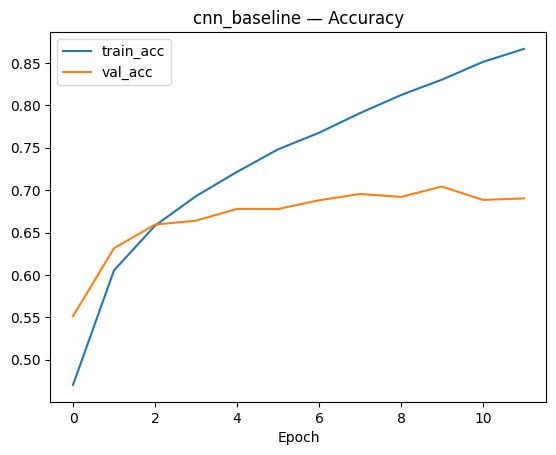

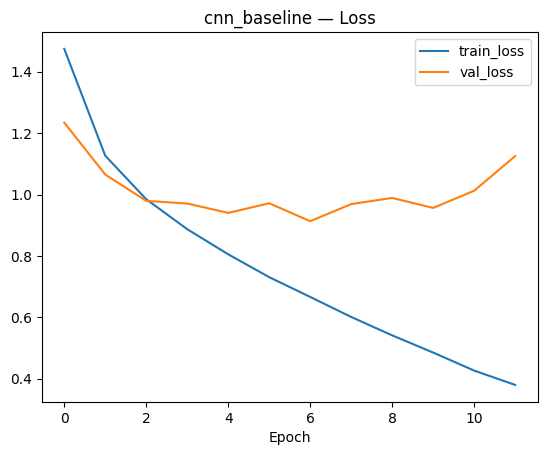

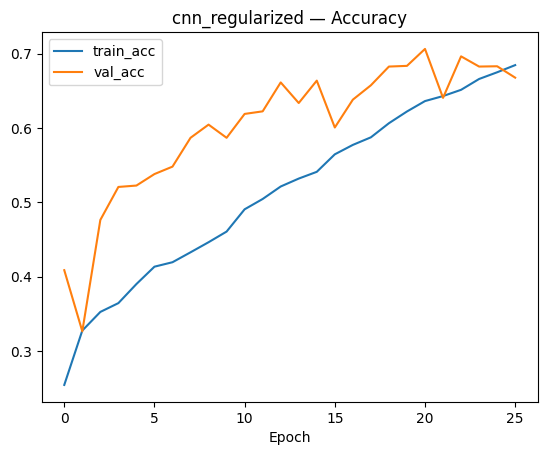

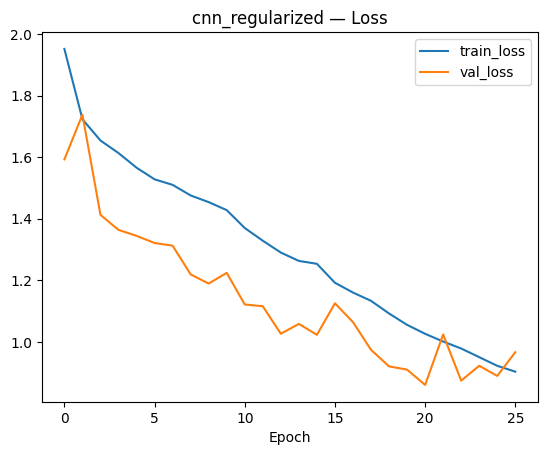

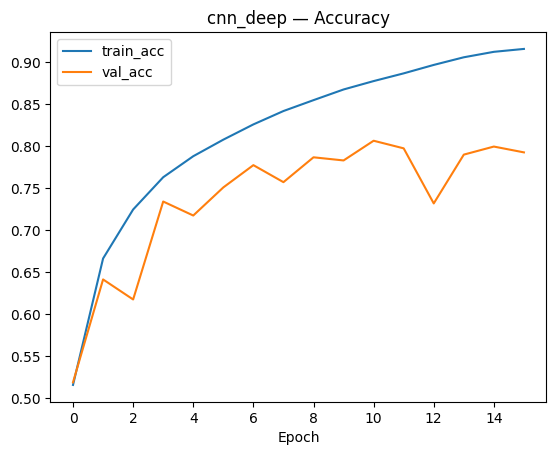

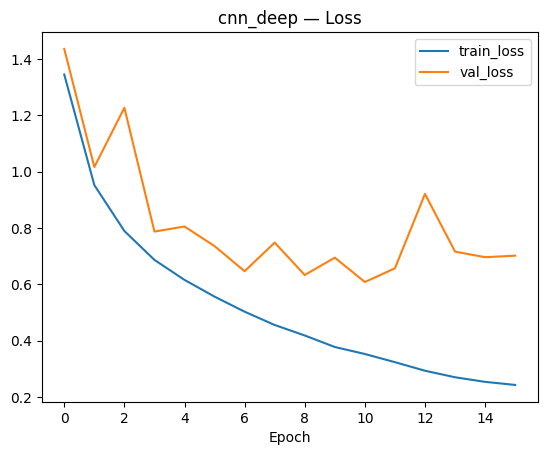

In [ ]:
def plot_history(history, name):
    plt.figure()
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(f'{name} — Accuracy'); plt.xlabel('Epoch'); plt.legend()
    plt.savefig(f'results/training_history_{name}_acc.png'); plt.show()

    plt.figure()
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'{name} — Loss'); plt.xlabel('Epoch'); plt.legend()
    plt.savefig(f'results/training_history_{name}_loss.png'); plt.show()

plot_history(history_baseline, "cnn_baseline")
plot_history(history_regularized, "cnn_regularized")
plot_history(history_deep, "cnn_deep")

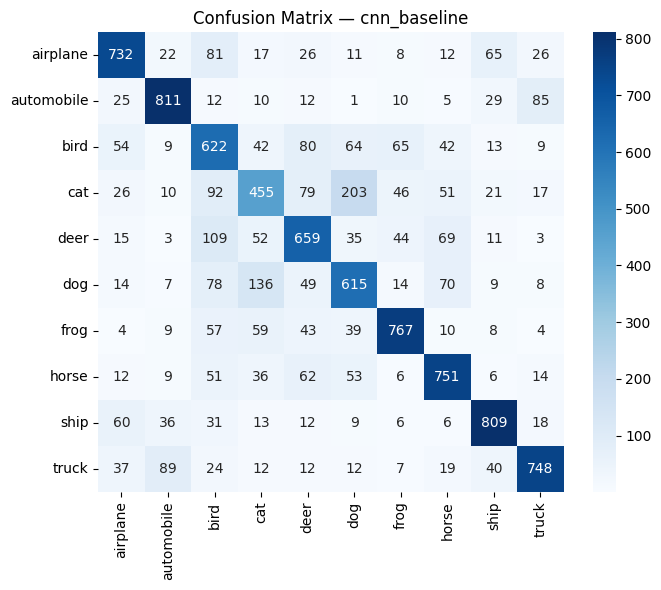

{'model': 'cnn_baseline', 'accuracy': 0.6969, 'precision': 0.6983341486365623, 'recall': 0.6969000000000001, 'f1': 0.6967013543263353}


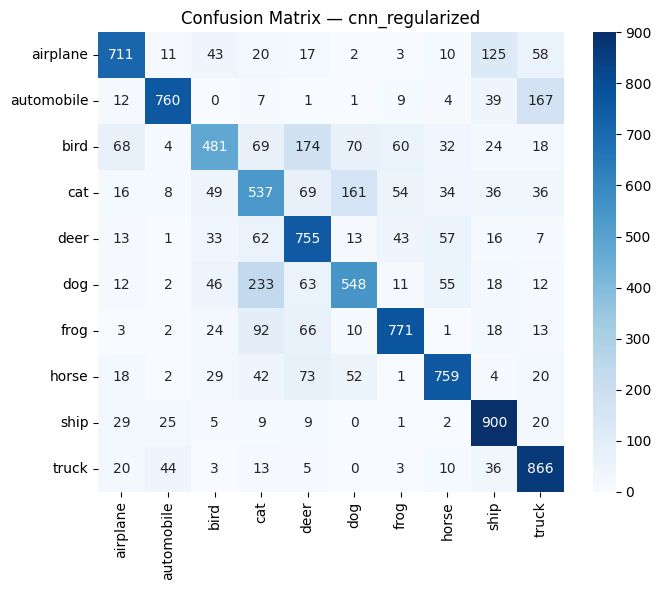

{'model': 'cnn_regularized', 'accuracy': 0.7088, 'precision': 0.7140811587415347, 'recall': 0.7088, 'f1': 0.7063709706000485}


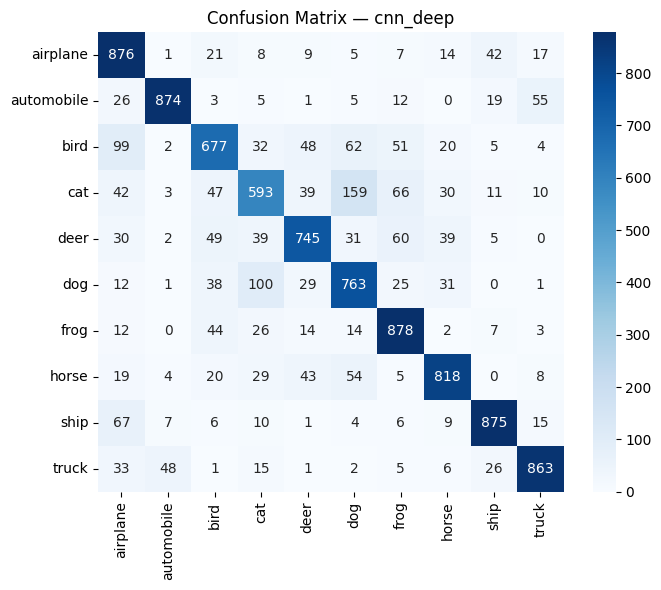

{'model': 'cnn_deep', 'accuracy': 0.7962, 'precision': 0.7982412849424222, 'recall': 0.7962, 'f1': 0.7952820486144552}


,model,accuracy,precision,recall,f1
0,cnn_baseline,0.6969,0.698334,0.6969,0.696701
1,cnn_regularized,0.7088,0.714081,0.7088,0.706371
2,cnn_deep,0.7962,0.798241,0.7962,0.795282


In [ ]:
from tensorflow.keras.models import load_model

cnn_baseline = load_model('models/cnn_baseline.keras')
cnn_regularized = load_model('models/cnn_regularized.keras')
cnn_deep = load_model('models/cnn_deep.keras')

models_list = [cnn_baseline, cnn_regularized, cnn_deep]
model_names = ['cnn_baseline', 'cnn_regularized', 'cnn_deep']

y_true = np.argmax(y_test, axis=1)

def evaluate_model(model, name):
    probs = model.predict(x_test, verbose=0)
    preds = np.argmax(probs, axis=1)
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_true, preds),
        'precision': precision_score(y_true, preds, average='macro'),
        'recall': recall_score(y_true, preds, average='macro'),
        'f1': f1_score(y_true, preds, average='macro'),
    }
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix — {name}'); plt.tight_layout()
    plt.savefig(f'results/confusion_matrix_{name}.png'); plt.show()
    return metrics, probs

individual_results = []
probs_list_test = []
for name, model in zip(model_names, models_list):
    metrics, probs = evaluate_model(model, name)
    individual_results.append(metrics)
    probs_list_test.append(probs)
    print(metrics)

individual_df = pd.DataFrame(individual_results)
individual_df.to_csv('results/individual_cnn_results.csv', index=False)
individual_df

In [ ]:
def majority_voting(probs_list):
    preds = np.array([np.argmax(p, axis=1) for p in probs_list])
    return np.array([
        np.bincount(preds[:, i], minlength=NUM_CLASSES).argmax()
        for i in range(preds.shape[1])
    ])

def soft_voting(probs_list):
    avg = np.mean(probs_list, axis=0)
    return np.argmax(avg, axis=1), avg

def weighted_soft_voting(probs_list, weights):
    weights = np.array(weights) / np.sum(weights)
    avg = np.zeros_like(probs_list[0])
    for w, p in zip(weights, probs_list):
        avg += w * p
    return np.argmax(avg, axis=1), avg

def score(y_true, y_pred, name):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro'),
        'recall': recall_score(y_true, y_pred, average='macro'),
        'f1': f1_score(y_true, y_pred, average='macro'),
    }

# Weighted voting weights come from VALIDATION accuracy only, never test
y_val_true = np.argmax(y_val, axis=1)
val_weights = []
for m in models_list:
    preds = np.argmax(m.predict(x_val, verbose=0), axis=1)
    val_weights.append(accuracy_score(y_val_true, preds))
print('Validation-based weights:', dict(zip(model_names, val_weights)))

ensemble_results = []

maj_pred = majority_voting(probs_list_test)
ensemble_results.append(score(y_true, maj_pred, 'majority_voting'))

soft_pred, soft_avg = soft_voting(probs_list_test)
ensemble_results.append(score(y_true, soft_pred, 'soft_voting'))

wsoft_pred, wsoft_avg = weighted_soft_voting(probs_list_test, val_weights)
ensemble_results.append(score(y_true, wsoft_pred, 'weighted_soft_voting'))

ensemble_df = pd.DataFrame(ensemble_results)
ensemble_df.to_csv('results/ensemble_results.csv', index=False)
ensemble_df

Validation-based weights: {'cnn_baseline': 0.7042666666666667, 'cnn_regularized': 0.7064, 'cnn_deep': 0.8062666666666667}


,model,accuracy,precision,recall,f1
0,majority_voting,0.7801,0.781823,0.7801,0.780006
1,soft_voting,0.8066,0.804652,0.8066,0.804717
2,weighted_soft_voting,0.8092,0.807402,0.8092,0.807374


In [ ]:
import psutil

N_RUNS = 50

def measure_latency(model, sample, n_runs=N_RUNS):
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        model.predict(sample, verbose=0)
        times.append((time.perf_counter() - start) * 1000)
    return {'avg_latency_ms': float(np.mean(times)), 'min_latency_ms': float(np.min(times)), 'max_latency_ms': float(np.max(times))}

def measure_throughput(model, x_batch):
    start = time.perf_counter()
    model.predict(x_batch, verbose=0)
    return len(x_batch) / (time.perf_counter() - start)

def get_model_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

def measure_memory_mb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

sample = x_test[:1]
x_batch = x_test[:64]
model_paths = {n: f'models/{n}.keras' for n in model_names}

benchmark_results = []
for name, model in zip(model_names, models_list):
    mem_before = measure_memory_mb()
    lat = measure_latency(model, sample)
    thr = measure_throughput(model, x_batch)
    mem_after = measure_memory_mb()
    row = {**lat, 'throughput_img_per_sec': thr,
           'model_size_mb': get_model_size_mb(model_paths[name]),
           'parameters': model.count_params(),
           'memory_mb': mem_after - mem_before, 'model': name}
    benchmark_results.append(row)
    print(name, row)

# Sequential ensemble benchmark
mem_before = measure_memory_mb()
times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    for m in models_list:
        m.predict(sample, verbose=0)
    times.append((time.perf_counter() - start) * 1000)

start = time.perf_counter()
for m in models_list:
    m.predict(x_batch, verbose=0)
ens_throughput = len(x_batch) / (time.perf_counter() - start)
mem_after = measure_memory_mb()

ensemble_bench = {
    'avg_latency_ms': float(np.mean(times)), 'min_latency_ms': float(np.min(times)), 'max_latency_ms': float(np.max(times)),
    'throughput_img_per_sec': ens_throughput,
    'model_size_mb': sum(get_model_size_mb(p) for p in model_paths.values()),
    'parameters': sum(m.count_params() for m in models_list),
    'memory_mb': mem_after - mem_before, 'model': 'ensemble_sequential',
}
benchmark_results.append(ensemble_bench)
print('ensemble', ensemble_bench)

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df.to_csv('results/benchmark_results.csv', index=False)
benchmark_df

cnn_baseline {'avg_latency_ms': 73.86312231997181, 'min_latency_ms': 62.27233999970849, 'max_latency_ms': 494.02123900017614, 'throughput_img_per_sec': 809.531668725847, 'model_size_mb': 3.6488733291625977, 'parameters': 315722, 'memory_mb': 5.66015625, 'model': 'cnn_baseline'}
cnn_regularized {'avg_latency_ms': 92.49673892001738, 'min_latency_ms': 62.842171000284, 'max_latency_ms': 450.482199000362, 'throughput_img_per_sec': 939.1739170063881, 'model_size_mb': 6.2991180419921875, 'parameters': 545482, 'memory_mb': 2.890625, 'model': 'cnn_regularized'}
cnn_deep {'avg_latency_ms': 76.39469559996542, 'min_latency_ms': 59.66699800001152, 'max_latency_ms': 655.5367619998833, 'throughput_img_per_sec': 939.3990171283392, 'model_size_mb': 1.87646484375, 'parameters': 158122, 'memory_mb': 2.375, 'model': 'cnn_deep'}
ensemble {'avg_latency_ms': 219.90115616002186, 'min_latency_ms': 190.61648900014916, 'max_latency_ms': 357.32806199985134, 'throughput_img_per_sec': 246.84056419859624, 'model_siz

,avg_latency_ms,min_latency_ms,max_latency_ms,throughput_img_per_sec,model_size_mb,parameters,memory_mb,model
0,73.863122,62.272340,494.021239,809.531669,3.648873,315722,5.660156,cnn_baseline
1,92.496739,62.842171,450.482199,939.173917,6.299118,545482,2.890625,cnn_regularized
2,76.394696,59.666998,655.536762,939.399017,1.876465,158122,2.375000,cnn_deep
3,219.901156,190.616489,357.328062,246.840564,11.824456,1019326,0.828125,ensemble_sequential


In [ ]:
from scipy.ndimage import rotate, gaussian_filter

N_SAMPLES = 200
x_sub = x_test[:N_SAMPLES]
y_true_sub = np.argmax(y_test[:N_SAMPLES], axis=1)

def make_rotated(x): return np.array([rotate(img, 25, reshape=False, mode='nearest') for img in x])
def make_blurred(x): return np.array([gaussian_filter(img, sigma=(1.2, 1.2, 0)) for img in x])
def make_noisy(x): return np.clip(x + np.random.normal(0, 0.08, x.shape), 0, 1)
def make_dark(x): return np.clip(x * 0.4, 0, 1)
def make_bright(x): return np.clip(x * 1.6, 0, 1)
def make_cropped(x):
    out = x.copy(); out[:, :6, :, :] = 0; out[:, -6:, :, :] = 0
    return out

TRANSFORMS = {
    'original': lambda x: x, 'rotated': make_rotated, 'blurred': make_blurred,
    'noisy': make_noisy, 'dark': make_dark, 'bright': make_bright, 'cropped': make_cropped,
}

def get_all_probs(models, x):
    return [m.predict(x, verbose=0) for m in models]

robustness_results = []
for transform_name, fn in TRANSFORMS.items():
    x_mod = fn(x_sub)
    probs_list = get_all_probs(models_list, x_mod)
    row = {}
    for name, probs in zip(model_names, probs_list):
        preds = np.argmax(probs, axis=1)
        row[name] = float(np.mean(preds == y_true_sub))
    ens_pred, _ = soft_voting(probs_list)
    row['ensemble_soft'] = float(np.mean(ens_pred == y_true_sub))
    row['condition'] = transform_name
    robustness_results.append(row)
    print(transform_name, row)

robustness_df = pd.DataFrame(robustness_results)
robustness_df.to_csv('results/robustness_results.csv', index=False)
robustness_df

original {'cnn_baseline': 0.685, 'cnn_regularized': 0.72, 'cnn_deep': 0.82, 'ensemble_soft': 0.82, 'condition': 'original'}
rotated {'cnn_baseline': 0.52, 'cnn_regularized': 0.575, 'cnn_deep': 0.58, 'ensemble_soft': 0.64, 'condition': 'rotated'}
blurred {'cnn_baseline': 0.42, 'cnn_regularized': 0.355, 'cnn_deep': 0.235, 'ensemble_soft': 0.39, 'condition': 'blurred'}
noisy {'cnn_baseline': 0.635, 'cnn_regularized': 0.51, 'cnn_deep': 0.435, 'ensemble_soft': 0.63, 'condition': 'noisy'}
dark {'cnn_baseline': 0.5, 'cnn_regularized': 0.45, 'cnn_deep': 0.71, 'ensemble_soft': 0.695, 'condition': 'dark'}
bright {'cnn_baseline': 0.665, 'cnn_regularized': 0.67, 'cnn_deep': 0.745, 'ensemble_soft': 0.78, 'condition': 'bright'}
cropped {'cnn_baseline': 0.37, 'cnn_regularized': 0.355, 'cnn_deep': 0.535, 'ensemble_soft': 0.5, 'condition': 'cropped'}


,cnn_baseline,cnn_regularized,cnn_deep,ensemble_soft,condition
0,0.685,0.720,0.820,0.820,original
1,0.520,0.575,0.580,0.640,rotated
2,0.420,0.355,0.235,0.390,blurred
3,0.635,0.510,0.435,0.630,noisy
4,0.500,0.450,0.710,0.695,dark
5,0.665,0.670,0.745,0.780,bright
6,0.370,0.355,0.535,0.500,cropped


In [ ]:
best_individual = individual_df.loc[individual_df['accuracy'].idxmax()]
best_ensemble = ensemble_df.loc[ensemble_df['accuracy'].idxmax()]

acc_improvement = (best_ensemble['accuracy'] - best_individual['accuracy']) * 100

best_cnn_bench = benchmark_df[benchmark_df['model'] == best_individual['model']].iloc[0]
ensemble_bench_row = benchmark_df[benchmark_df['model'] == 'ensemble_sequential'].iloc[0]
latency_increase = ensemble_bench_row['avg_latency_ms'] - best_cnn_bench['avg_latency_ms']
throughput_drop = best_cnn_bench['throughput_img_per_sec'] - ensemble_bench_row['throughput_img_per_sec']
memory_increase = ensemble_bench_row['memory_mb'] - best_cnn_bench['memory_mb']

print(f"Best individual CNN: {best_individual['model']} ({best_individual['accuracy']*100:.2f}% accuracy)")
print(f"Best ensemble strategy: {best_ensemble['model']} ({best_ensemble['accuracy']*100:.2f}% accuracy)")
print(f"Accuracy improvement: {acc_improvement:.2f} percentage points")
print(f"Latency increase (ensemble vs best CNN): {latency_increase:.2f} ms")
print(f"Throughput drop: {throughput_drop:.1f} img/sec")
print(f"Memory increase: {memory_increase:.1f} MB")
print()
print('Robustness (accuracy under each condition):')
print(robustness_df.set_index('condition')[[best_individual['model'], 'ensemble_soft']])

Best individual CNN: cnn_deep (79.62% accuracy)
Best ensemble strategy: weighted_soft_voting (80.92% accuracy)
Accuracy improvement: 1.30 percentage points
Latency increase (ensemble vs best CNN): 143.51 ms
Throughput drop: 692.6 img/sec
Memory increase: -1.5 MB

Robustness (accuracy under each condition):
           cnn_deep  ensemble_soft
condition                         
original      0.820          0.820
rotated       0.580          0.640
blurred       0.235          0.390
noisy         0.435          0.630
dark          0.710          0.695
bright        0.745          0.780
cropped       0.535          0.500


In [ ]:
BATCH_SIZE = 32
MAX_EPOCHS = 30

def get_callbacks(name):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"models/{name}.keras", monitor='val_accuracy', save_best_only=True),
    ]

def train_model(model, name):
    print(f"=== Training {name} ===")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=MAX_EPOCHS,
        callbacks=get_callbacks(name),
        verbose=2,
    )
    return history

history_baseline = train_model(cnn_baseline, "cnn_baseline")
history_regularized = train_model(cnn_regularized, "cnn_regularized")
history_deep = train_model(cnn_deep, "cnn_deep")

=== Training cnn_baseline ===
Epoch 1/30
1329/1329 - 10s - 8ms/step - accuracy: 0.8515 - loss: 0.4251 - val_accuracy: 0.6707 - val_loss: 1.0857
Epoch 2/30
1329/1329 - 6s - 4ms/step - accuracy: 0.8670 - loss: 0.3759 - val_accuracy: 0.6949 - val_loss: 1.1129
Epoch 3/30
1329/1329 - 5s - 4ms/step - accuracy: 0.8868 - loss: 0.3268 - val_accuracy: 0.6791 - val_loss: 1.1591
Epoch 4/30
1329/1329 - 5s - 4ms/step - accuracy: 0.9016 - loss: 0.2837 - val_accuracy: 0.6828 - val_loss: 1.2212
Epoch 5/30
1329/1329 - 10s - 7ms/step - accuracy: 0.9125 - loss: 0.2490 - val_accuracy: 0.6835 - val_loss: 1.4032
Epoch 6/30
1329/1329 - 6s - 4ms/step - accuracy: 0.9243 - loss: 0.2137 - val_accuracy: 0.6836 - val_loss: 1.4405
=== Training cnn_regularized ===
Epoch 1/30
1329/1329 - 15s - 11ms/step - accuracy: 0.6433 - loss: 1.0026 - val_accuracy: 0.6352 - val_loss: 1.0469
Epoch 2/30
1329/1329 - 6s - 5ms/step - accuracy: 0.6530 - loss: 0.9827 - val_accuracy: 0.7135 - val_loss: 0.8407
Epoch 3/30
1329/1329 - 6s - 4

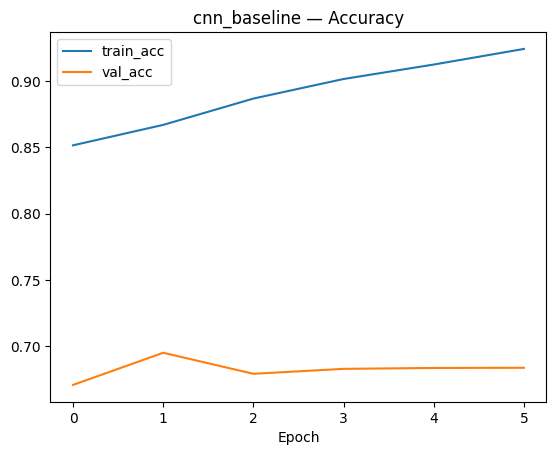

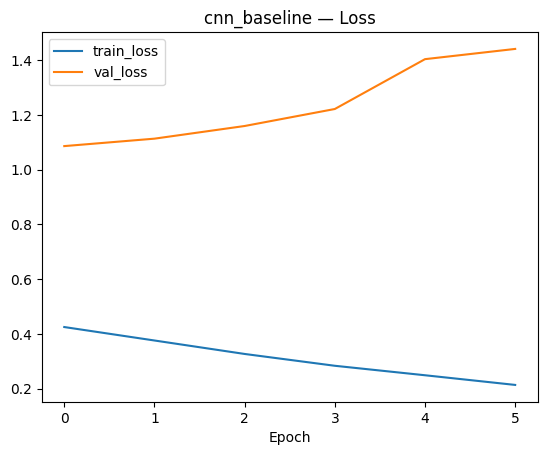

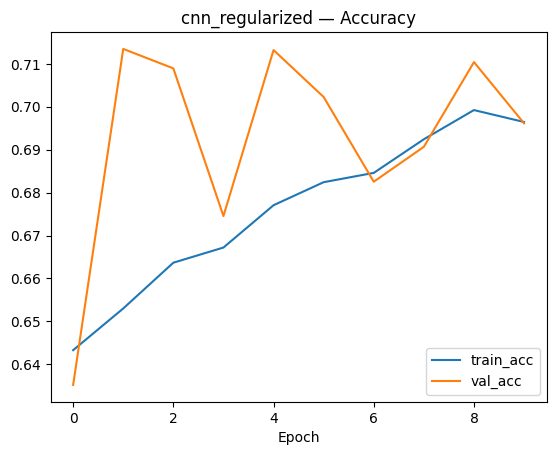

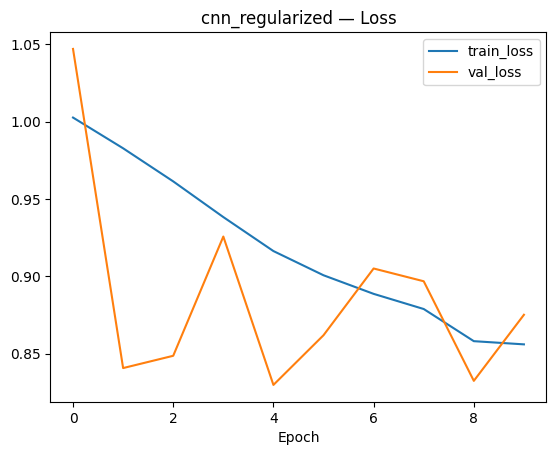

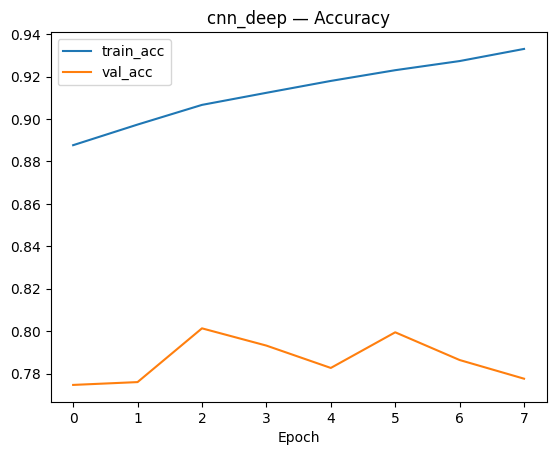

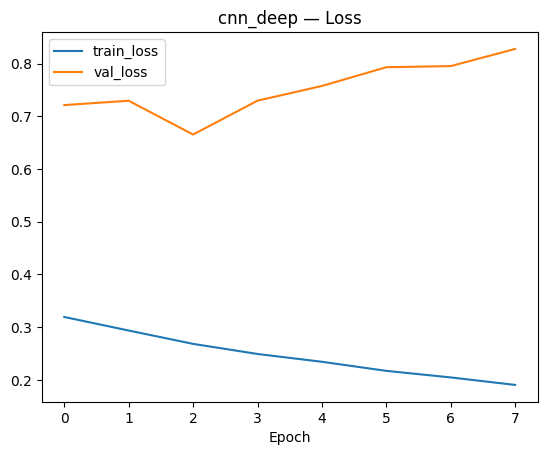

In [ ]:
def plot_history(history, name):
    plt.figure()
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(f'{name} — Accuracy'); plt.xlabel('Epoch'); plt.legend()
    plt.savefig(f'results/training_history_{name}_acc.png'); plt.show()

    plt.figure()
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'{name} — Loss'); plt.xlabel('Epoch'); plt.legend()
    plt.savefig(f'results/training_history_{name}_loss.png'); plt.show()

plot_history(history_baseline, "cnn_baseline")
plot_history(history_regularized, "cnn_regularized")
plot_history(history_deep, "cnn_deep")

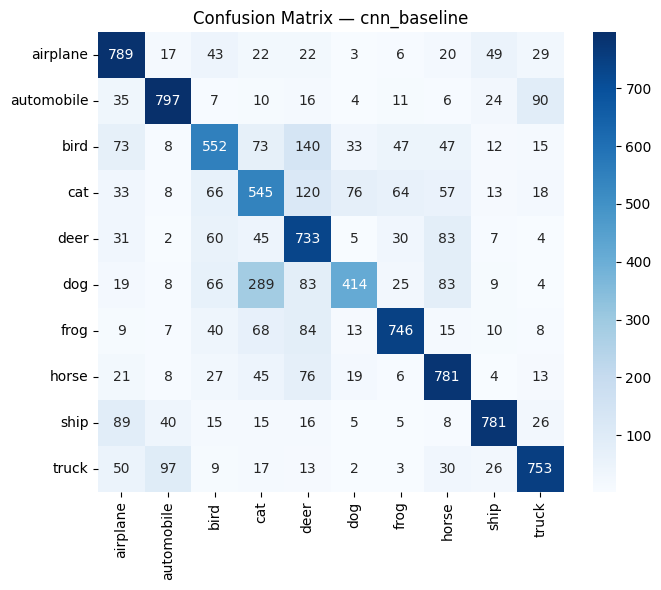

{'model': 'cnn_baseline', 'accuracy': 0.6891, 'precision': 0.6982282524472373, 'recall': 0.6891, 'f1': 0.6871579499686664}


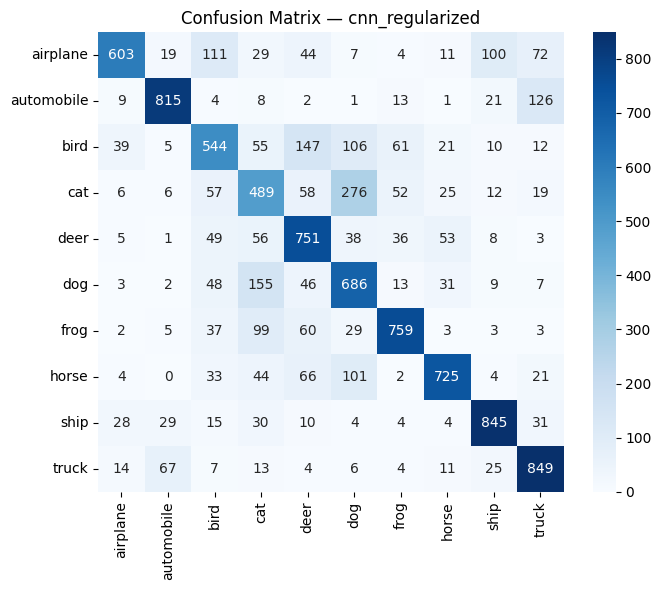

{'model': 'cnn_regularized', 'accuracy': 0.7066, 'precision': 0.7162304965515657, 'recall': 0.7066, 'f1': 0.7071579268603004}


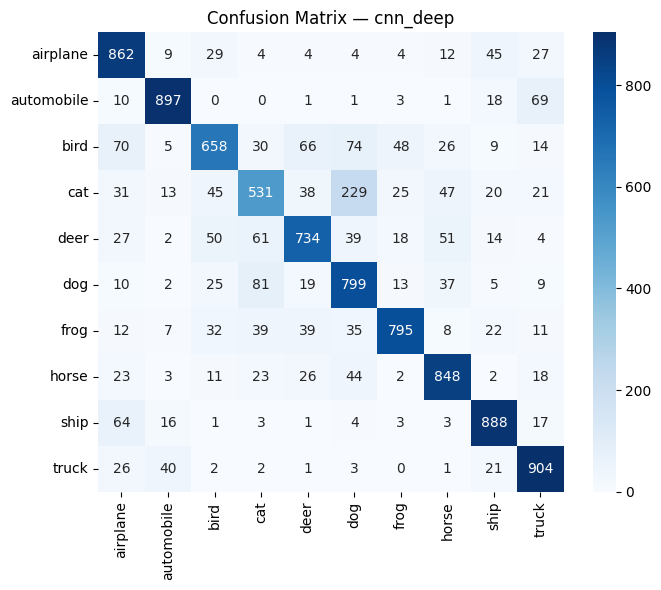

{'model': 'cnn_deep', 'accuracy': 0.7916, 'precision': 0.7927646856392702, 'recall': 0.7916000000000001, 'f1': 0.7891159861617436}


,model,accuracy,precision,recall,f1
0,cnn_baseline,0.6891,0.698228,0.6891,0.687158
1,cnn_regularized,0.7066,0.716230,0.7066,0.707158
2,cnn_deep,0.7916,0.792765,0.7916,0.789116


In [ ]:
from tensorflow.keras.models import load_model

cnn_baseline = load_model('models/cnn_baseline.keras')
cnn_regularized = load_model('models/cnn_regularized.keras')
cnn_deep = load_model('models/cnn_deep.keras')

models_list = [cnn_baseline, cnn_regularized, cnn_deep]
model_names = ['cnn_baseline', 'cnn_regularized', 'cnn_deep']

y_true = np.argmax(y_test, axis=1)

def evaluate_model(model, name):
    probs = model.predict(x_test, verbose=0)
    preds = np.argmax(probs, axis=1)
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_true, preds),
        'precision': precision_score(y_true, preds, average='macro'),
        'recall': recall_score(y_true, preds, average='macro'),
        'f1': f1_score(y_true, preds, average='macro'),
    }
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix — {name}'); plt.tight_layout()
    plt.savefig(f'results/confusion_matrix_{name}.png'); plt.show()
    return metrics, probs

individual_results = []
probs_list_test = []
for name, model in zip(model_names, models_list):
    metrics, probs = evaluate_model(model, name)
    individual_results.append(metrics)
    probs_list_test.append(probs)
    print(metrics)

individual_df = pd.DataFrame(individual_results)
individual_df.to_csv('results/individual_cnn_results.csv', index=False)
individual_df

In [ ]:
def majority_voting(probs_list):
    preds = np.array([np.argmax(p, axis=1) for p in probs_list])
    return np.array([
        np.bincount(preds[:, i], minlength=NUM_CLASSES).argmax()
        for i in range(preds.shape[1])
    ])

def soft_voting(probs_list):
    avg = np.mean(probs_list, axis=0)
    return np.argmax(avg, axis=1), avg

def weighted_soft_voting(probs_list, weights):
    weights = np.array(weights) / np.sum(weights)
    avg = np.zeros_like(probs_list[0])
    for w, p in zip(weights, probs_list):
        avg += w * p
    return np.argmax(avg, axis=1), avg

def score(y_true, y_pred, name):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro'),
        'recall': recall_score(y_true, y_pred, average='macro'),
        'f1': f1_score(y_true, y_pred, average='macro'),
    }

y_val_true = np.argmax(y_val, axis=1)
val_weights = []
for m in models_list:
    preds = np.argmax(m.predict(x_val, verbose=0), axis=1)
    val_weights.append(accuracy_score(y_val_true, preds))
print('Validation-based weights:', dict(zip(model_names, val_weights)))

ensemble_results = []

maj_pred = majority_voting(probs_list_test)
ensemble_results.append(score(y_true, maj_pred, 'majority_voting'))

soft_pred, soft_avg = soft_voting(probs_list_test)
ensemble_results.append(score(y_true, soft_pred, 'soft_voting'))

wsoft_pred, wsoft_avg = weighted_soft_voting(probs_list_test, val_weights)
ensemble_results.append(score(y_true, wsoft_pred, 'weighted_soft_voting'))

ensemble_df = pd.DataFrame(ensemble_results)
ensemble_df.to_csv('results/ensemble_results.csv', index=False)
ensemble_df

Validation-based weights: {'cnn_baseline': 0.6949333333333333, 'cnn_regularized': 0.7134666666666667, 'cnn_deep': 0.8013333333333333}


,model,accuracy,precision,recall,f1
0,majority_voting,0.7765,0.779212,0.7765,0.776898
1,soft_voting,0.8026,0.801807,0.8026,0.800920
2,weighted_soft_voting,0.8087,0.807570,0.8087,0.806903


In [ ]:
import psutil

N_RUNS = 50

def measure_latency(model, sample, n_runs=N_RUNS):
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        model.predict(sample, verbose=0)
        times.append((time.perf_counter() - start) * 1000)
    return {'avg_latency_ms': float(np.mean(times)), 'min_latency_ms': float(np.min(times)), 'max_latency_ms': float(np.max(times))}

def measure_throughput(model, x_batch):
    start = time.perf_counter()
    model.predict(x_batch, verbose=0)
    return len(x_batch) / (time.perf_counter() - start)

def get_model_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

def measure_memory_mb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

sample = x_test[:1]
x_batch = x_test[:64]
model_paths = {n: f'models/{n}.keras' for n in model_names}

benchmark_results = []
for name, model in zip(model_names, models_list):
    mem_before = measure_memory_mb()
    lat = measure_latency(model, sample)
    thr = measure_throughput(model, x_batch)
    mem_after = measure_memory_mb()
    row = {**lat, 'throughput_img_per_sec': thr,
           'model_size_mb': get_model_size_mb(model_paths[name]),
           'parameters': model.count_params(),
           'memory_mb': mem_after - mem_before, 'model': name}
    benchmark_results.append(row)
    print(name, row)

mem_before = measure_memory_mb()
times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    for m in models_list:
        m.predict(sample, verbose=0)
    times.append((time.perf_counter() - start) * 1000)

start = time.perf_counter()
for m in models_list:
    m.predict(x_batch, verbose=0)
ens_throughput = len(x_batch) / (time.perf_counter() - start)
mem_after = measure_memory_mb()

ensemble_bench = {
    'avg_latency_ms': float(np.mean(times)), 'min_latency_ms': float(np.min(times)), 'max_latency_ms': float(np.max(times)),
    'throughput_img_per_sec': ens_throughput,
    'model_size_mb': sum(get_model_size_mb(p) for p in model_paths.values()),
    'parameters': sum(m.count_params() for m in models_list),
    'memory_mb': mem_after - mem_before, 'model': 'ensemble_sequential',
}
benchmark_results.append(ensemble_bench)
print('ensemble', ensemble_bench)

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df.to_csv('results/benchmark_results.csv', index=False)
benchmark_df

cnn_baseline {'avg_latency_ms': 78.53604384004939, 'min_latency_ms': 64.69888200035712, 'max_latency_ms': 387.58186200038836, 'throughput_img_per_sec': 816.6239942357288, 'model_size_mb': 3.6486263275146484, 'parameters': 315722, 'memory_mb': -13.4375, 'model': 'cnn_baseline'}
cnn_regularized {'avg_latency_ms': 94.74719990000267, 'min_latency_ms': 65.93175999978484, 'max_latency_ms': 379.1717389999576, 'throughput_img_per_sec': 923.3202845572528, 'model_size_mb': 6.298624038696289, 'parameters': 545482, 'memory_mb': 1.9296875, 'model': 'cnn_regularized'}
cnn_deep {'avg_latency_ms': 73.14095208002072, 'min_latency_ms': 63.15683299999364, 'max_latency_ms': 366.42173100017317, 'throughput_img_per_sec': 906.3019835872841, 'model_size_mb': 1.8759708404541016, 'parameters': 158122, 'memory_mb': 2.81640625, 'model': 'cnn_deep'}
ensemble {'avg_latency_ms': 227.87201382000603, 'min_latency_ms': 191.0204320001867, 'max_latency_ms': 391.62858600002437, 'throughput_img_per_sec': 289.42653767461553

,avg_latency_ms,min_latency_ms,max_latency_ms,throughput_img_per_sec,model_size_mb,parameters,memory_mb,model
0,78.536044,64.698882,387.581862,816.623994,3.648626,315722,-13.437500,cnn_baseline
1,94.747200,65.931760,379.171739,923.320285,6.298624,545482,1.929688,cnn_regularized
2,73.140952,63.156833,366.421731,906.301984,1.875971,158122,2.816406,cnn_deep
3,227.872014,191.020432,391.628586,289.426538,11.823221,1019326,-0.253906,ensemble_sequential


In [ ]:
from scipy.ndimage import rotate, gaussian_filter

N_SAMPLES = 200
x_sub = x_test[:N_SAMPLES]
y_true_sub = np.argmax(y_test[:N_SAMPLES], axis=1)

def make_rotated(x): return np.array([rotate(img, 25, reshape=False, mode='nearest') for img in x])
def make_blurred(x): return np.array([gaussian_filter(img, sigma=(1.2, 1.2, 0)) for img in x])
def make_noisy(x): return np.clip(x + np.random.normal(0, 0.08, x.shape), 0, 1)
def make_dark(x): return np.clip(x * 0.4, 0, 1)
def make_bright(x): return np.clip(x * 1.6, 0, 1)
def make_cropped(x):
    out = x.copy(); out[:, :6, :, :] = 0; out[:, -6:, :, :] = 0
    return out

TRANSFORMS = {
    'original': lambda x: x, 'rotated': make_rotated, 'blurred': make_blurred,
    'noisy': make_noisy, 'dark': make_dark, 'bright': make_bright, 'cropped': make_cropped,
}

def get_all_probs(models, x):
    return [m.predict(x, verbose=0) for m in models]

robustness_results = []
for transform_name, fn in TRANSFORMS.items():
    x_mod = fn(x_sub)
    probs_list = get_all_probs(models_list, x_mod)
    row = {}
    for name, probs in zip(model_names, probs_list):
        preds = np.argmax(probs, axis=1)
        row[name] = float(np.mean(preds == y_true_sub))
    ens_pred, _ = soft_voting(probs_list)
    row['ensemble_soft'] = float(np.mean(ens_pred == y_true_sub))
    row['condition'] = transform_name
    robustness_results.append(row)
    print(transform_name, row)

robustness_df = pd.DataFrame(robustness_results)
robustness_df.to_csv('results/robustness_results.csv', index=False)
robustness_df

original {'cnn_baseline': 0.71, 'cnn_regularized': 0.745, 'cnn_deep': 0.825, 'ensemble_soft': 0.86, 'condition': 'original'}
rotated {'cnn_baseline': 0.47, 'cnn_regularized': 0.535, 'cnn_deep': 0.625, 'ensemble_soft': 0.66, 'condition': 'rotated'}
blurred {'cnn_baseline': 0.43, 'cnn_regularized': 0.365, 'cnn_deep': 0.32, 'ensemble_soft': 0.41, 'condition': 'blurred'}
noisy {'cnn_baseline': 0.62, 'cnn_regularized': 0.5, 'cnn_deep': 0.61, 'ensemble_soft': 0.655, 'condition': 'noisy'}
dark {'cnn_baseline': 0.5, 'cnn_regularized': 0.46, 'cnn_deep': 0.675, 'ensemble_soft': 0.705, 'condition': 'dark'}
bright {'cnn_baseline': 0.655, 'cnn_regularized': 0.69, 'cnn_deep': 0.745, 'ensemble_soft': 0.79, 'condition': 'bright'}
cropped {'cnn_baseline': 0.35, 'cnn_regularized': 0.4, 'cnn_deep': 0.485, 'ensemble_soft': 0.465, 'condition': 'cropped'}


,cnn_baseline,cnn_regularized,cnn_deep,ensemble_soft,condition
0,0.710,0.745,0.825,0.860,original
1,0.470,0.535,0.625,0.660,rotated
2,0.430,0.365,0.320,0.410,blurred
3,0.620,0.500,0.610,0.655,noisy
4,0.500,0.460,0.675,0.705,dark
5,0.655,0.690,0.745,0.790,bright
6,0.350,0.400,0.485,0.465,cropped


In [ ]:
best_individual = individual_df.loc[individual_df['accuracy'].idxmax()]
best_ensemble = ensemble_df.loc[ensemble_df['accuracy'].idxmax()]

acc_improvement = (best_ensemble['accuracy'] - best_individual['accuracy']) * 100

best_cnn_bench = benchmark_df[benchmark_df['model'] == best_individual['model']].iloc[0]
ensemble_bench_row = benchmark_df[benchmark_df['model'] == 'ensemble_sequential'].iloc[0]
latency_increase = ensemble_bench_row['avg_latency_ms'] - best_cnn_bench['avg_latency_ms']
throughput_drop = best_cnn_bench['throughput_img_per_sec'] - ensemble_bench_row['throughput_img_per_sec']
memory_increase = ensemble_bench_row['memory_mb'] - best_cnn_bench['memory_mb']

print(f"Best individual CNN: {best_individual['model']} ({best_individual['accuracy']*100:.2f}% accuracy)")
print(f"Best ensemble strategy: {best_ensemble['model']} ({best_ensemble['accuracy']*100:.2f}% accuracy)")
print(f"Accuracy improvement: {acc_improvement:.2f} percentage points")
print(f"Latency increase (ensemble vs best CNN): {latency_increase:.2f} ms")
print(f"Throughput drop: {throughput_drop:.1f} img/sec")
print(f"Memory increase: {memory_increase:.1f} MB")
print()
print('Robustness (accuracy under each condition):')
print(robustness_df.set_index('condition')[[best_individual['model'], 'ensemble_soft']])

Best individual CNN: cnn_deep (79.16% accuracy)
Best ensemble strategy: weighted_soft_voting (80.87% accuracy)
Accuracy improvement: 1.71 percentage points
Latency increase (ensemble vs best CNN): 154.73 ms
Throughput drop: 616.9 img/sec
Memory increase: -3.1 MB

Robustness (accuracy under each condition):
           cnn_deep  ensemble_soft
condition                         
original      0.825          0.860
rotated       0.625          0.660
blurred       0.320          0.410
noisy         0.610          0.655
dark          0.675          0.705
bright        0.745          0.790
cropped       0.485          0.465


In [ ]:
print(open('results/individual_cnn_results.csv').read())
print(open('results/ensemble_results.csv').read())
print(open('results/benchmark_results.csv').read())

model,accuracy,precision,recall,f1
cnn_baseline,0.6891,0.6982282524472373,0.6891,0.6871579499686664
cnn_regularized,0.7066,0.7162304965515657,0.7066,0.7071579268603004
cnn_deep,0.7916,0.7927646856392702,0.7916000000000001,0.7891159861617436

model,accuracy,precision,recall,f1
majority_voting,0.7765,0.7792115593563795,0.7765000000000001,0.776897783578476
soft_voting,0.8026,0.8018069655194953,0.8026,0.8009201621161759
weighted_soft_voting,0.8087,0.8075695437161853,0.8087,0.8069032874816798

avg_latency_ms,min_latency_ms,max_latency_ms,throughput_img_per_sec,model_size_mb,parameters,memory_mb,model
78.53604384004939,64.69888200035712,387.58186200038836,816.6239942357288,3.6486263275146484,315722,-13.4375,cnn_baseline
94.74719990000267,65.93175999978484,379.1717389999576,923.3202845572528,6.298624038696289,545482,1.9296875,cnn_regularized
73.14095208002072,63.15683299999364,366.42173100017317,906.3019835872841,1.8759708404541016,158122,2.81640625,cnn_deep
227.87201382000603,191.02043200018

In [ ]:
import shutil

shutil.make_archive('results_zip', 'zip', 'results')
shutil.make_archive('models_zip', 'zip', 'models')

from google.colab import files
files.download('results_zip.zip')
files.download('models_zip.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>